In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

sns.set_theme(style="whitegrid")


In [13]:
FILE_PATH = "defects.csv"

df = pd.read_csv(FILE_PATH)

df['Sample_dt'] = pd.to_datetime(df['Sample'], format='%H:%M')
df['date'] = pd.to_datetime("2024-01-01") + pd.to_timedelta(df["Day"] - 1, unit="D")
df["timestamp"] = df["date"].dt.floor("D") + df["Sample_dt"].dt.time.astype(str).map(
    lambda x: pd.to_timedelta(x)
)

df['hours'] = df['Sample_dt'].dt.hour
df['min'] = df['Sample_dt'].dt.minute
# сортировка по времени
df = df.sort_values(["Day", "Sample_dt"]).reset_index(drop=True)

# индекс
df["t"] = np.arange(1, len(df) + 1)

# выбираем нужное
df = df[["t", "Day", "Sample", "Sample_dt", "timestamp", "Defects", "hours", "min"]]


df[:20]

,t,Day,Sample,Sample_dt,timestamp,Defects,hours,min
0,1,1,08:15,1900-01-01 08:15:00,2024-01-01 08:15:00,12,8,15
1,2,1,08:30,1900-01-01 08:30:00,2024-01-01 08:30:00,8,8,30
2,3,1,08:45,1900-01-01 08:45:00,2024-01-01 08:45:00,9,8,45
3,4,1,09:00,1900-01-01 09:00:00,2024-01-01 09:00:00,11,9,0
4,5,1,09:15,1900-01-01 09:15:00,2024-01-01 09:15:00,9,9,15
5,6,1,09:30,1900-01-01 09:30:00,2024-01-01 09:30:00,10,9,30
6,7,1,09:45,1900-01-01 09:45:00,2024-01-01 09:45:00,12,9,45
7,8,1,10:00,1900-01-01 10:00:00,2024-01-01 10:00:00,9,10,0
8,9,1,10:15,1900-01-01 10:15:00,2024-01-01 10:15:00,12,10,15
9,10,1,10:30,1900-01-01 10:30:00,2024-01-01 10:30:00,4,10,30


# Проверка данных

In [14]:
# Проверка дубликатов по (Day, Sample)
print("Дубликаты по Day+Sample:", df.duplicated(subset=["Day", "Sample"]).sum())

# Проверка, что в каждом дне ровно 32 замера
counts_per_day = df.groupby("Day")["Defects"].count()
print("Количество наблюдений по дням:\n", counts_per_day)

print("Все дни содержат 32 замера?", (counts_per_day == 32).all())

# Проверка регулярности интервалов
diff_minutes = df.groupby("Day")["Sample_dt"].diff().dt.total_seconds().div(60).dropna()
print("Интервалы между точками (минуты):\n", diff_minutes.unique())

Дубликаты по Day+Sample: 0
Количество наблюдений по дням:
 Day
1     32
2     32
3     32
4     32
5     32
6     32
7     32
8     32
9     32
10    32
Name: Defects, dtype: int64
Все дни содержат 32 замера? True
Интервалы между точками (минуты):
 [15.]


In [15]:
desc = df["Defects"].describe()
print(desc)

# среднее, std, min, max
mean_val = df["Defects"].mean()
std_val = df["Defects"].std(ddof=1)
min_val = df["Defects"].min()
max_val = df["Defects"].max()

print(f"mean = {mean_val:.3f}")
print(f"std = {std_val:.3f}")
print(f"min = {min_val}")
print(f"max = {max_val}")

count    320.000000
mean      10.325000
std        3.172274
min        1.000000
25%        8.000000
50%       11.000000
75%       12.000000
max       18.000000
Name: Defects, dtype: float64
mean = 10.325
std = 3.172
min = 1
max = 18


# Гистограмма распределения

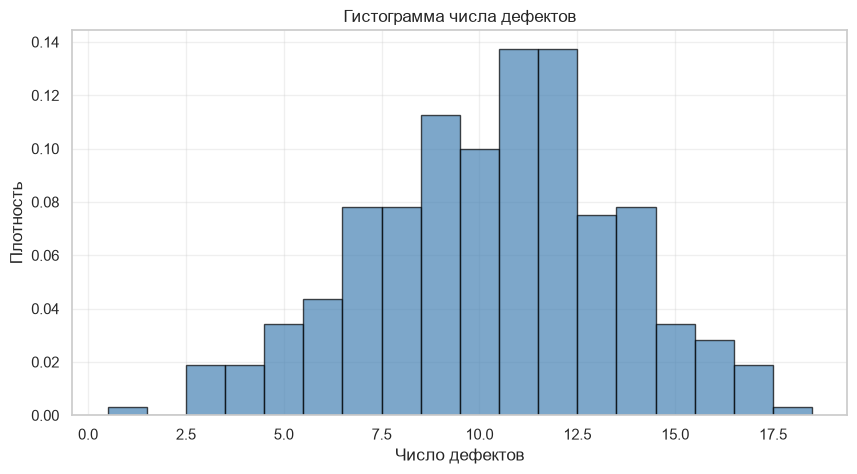

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(df["Defects"], bins=np.arange(df["Defects"].min(), df["Defects"].max() + 2) - 0.5,
         density=True, alpha=0.7, color="steelblue", edgecolor="black")
plt.title("Гистограмма числа дефектов")
plt.xlabel("Число дефектов")
plt.ylabel("Плотность")
plt.grid(alpha=0.3)
plt.show()

# Проверка на Пуассоновское распределение


In [17]:
x = df["Defects"]
mean = x.mean()
var = x.var(ddof=1)

print(f"Среднее: {mean:.4f}")
print(f"Дисперсия: {var:.4f}")
print(f"Отношение var/mean: {var/mean:.4f}")

Среднее: 10.3250
Дисперсия: 10.0633
Отношение var/mean: 0.9747


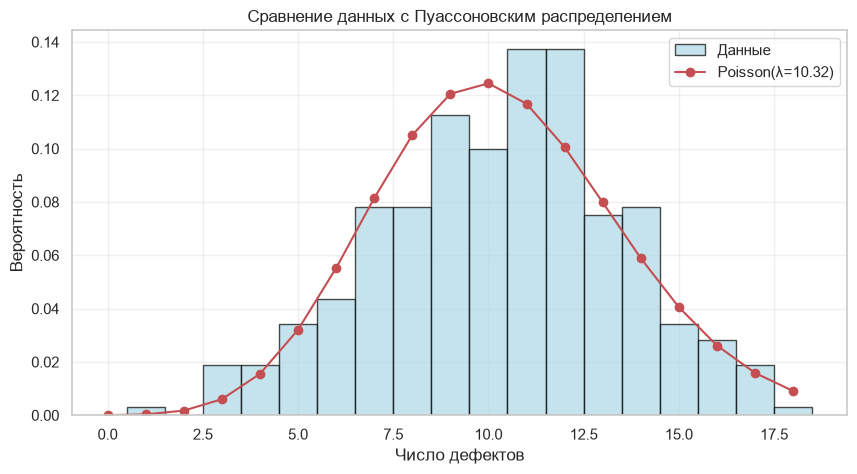

In [21]:
from scipy.stats import poisson

lam = df["Defects"].mean()
k = np.arange(0, df["Defects"].max() + 1)

plt.figure(figsize=(10, 5))
plt.hist(df["Defects"], bins=np.arange(df["Defects"].min(), df["Defects"].max() + 2) - 0.5,
         density=True, alpha=0.7, color="lightblue", edgecolor="black", label="Данные")
plt.plot(k, poisson.pmf(k, lam), "ro-", label=f"Poisson(λ={lam:.2f})")
plt.title("Сравнение данных с Пуассоновским распределением")
plt.xlabel("Число дефектов")
plt.ylabel("Вероятность")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
# Этап 1. Временной ряд и «опасные часы»

# Ряд дефектов, скользящее среднее, тепловая карта день × слот, профиль смены и средние по дням. По этим графикам потом решаем, что кластеризовать.


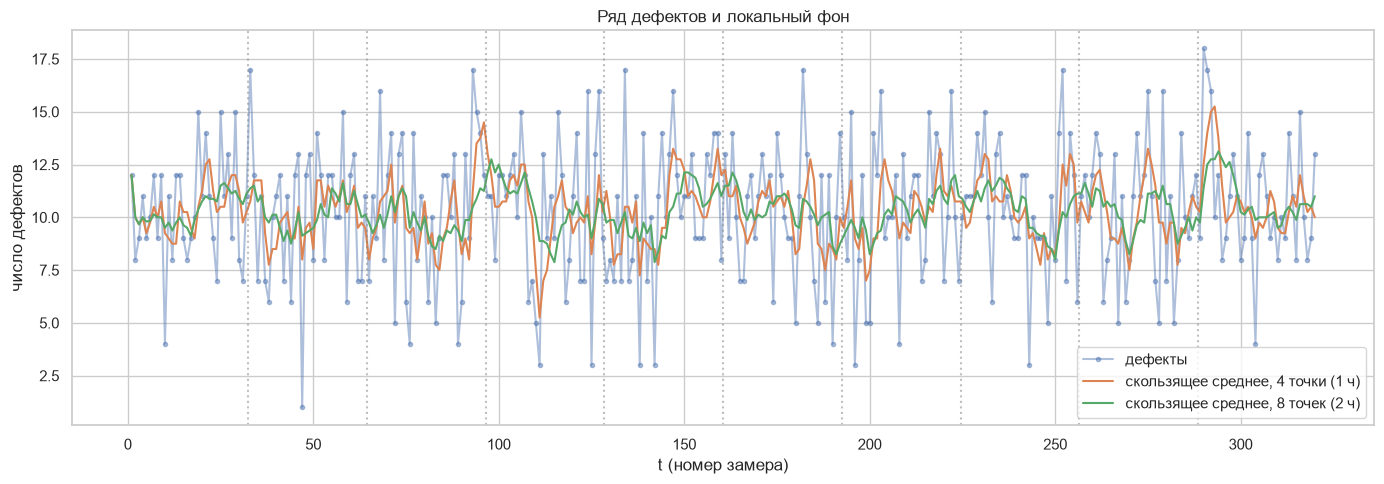

In [23]:
df["slot_idx"] = df.groupby("Day").cumcount() + 1
df["ma_4"] = df["Defects"].rolling(4, min_periods=1).mean()
df["ma_8"] = df["Defects"].rolling(8, min_periods=1).mean()
df["std_8"] = df["Defects"].rolling(8, min_periods=2).std()
df["delta"] = df["Defects"].diff()

plt.figure(figsize=(14, 5))
plt.plot(df["t"], df["Defects"], alpha=0.45, marker="o", ms=3, label="дефекты")
plt.plot(df["t"], df["ma_4"], label="скользящее среднее, 4 точки (1 ч)")
plt.plot(df["t"], df["ma_8"], label="скользящее среднее, 8 точек (2 ч)")
for day in range(2, int(df["Day"].max()) + 1):
    plt.axvline((day - 1) * 32 + 0.5, color="gray", ls=":", alpha=0.5)
plt.xlabel("t (номер замера)")
plt.ylabel("число дефектов")
plt.title("Ряд дефектов и локальный фон")
plt.legend()
plt.tight_layout()
plt.show()


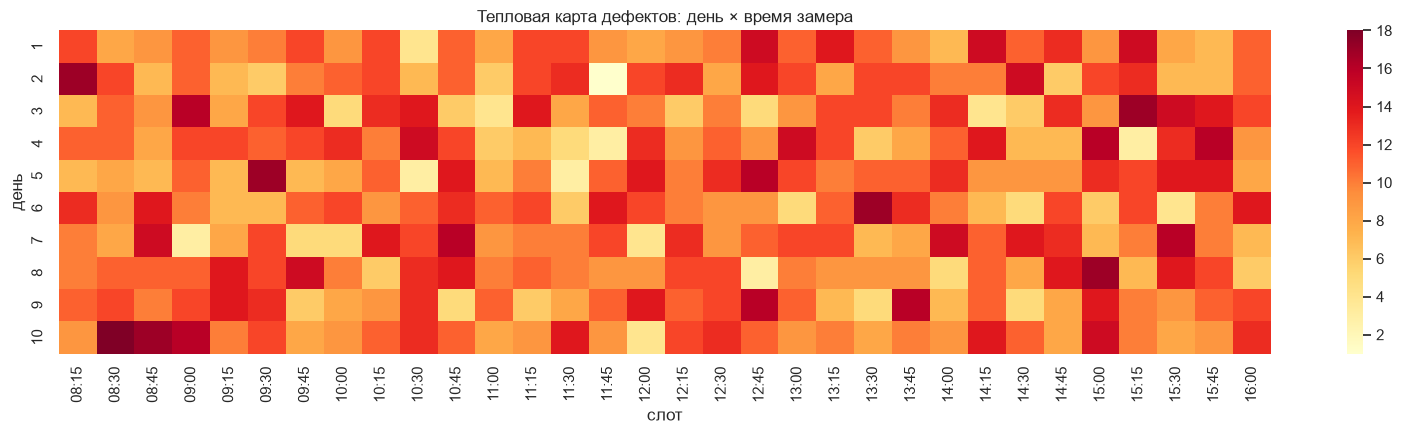

In [24]:
heat = df.pivot(index="Day", columns="Sample", values="Defects")

plt.figure(figsize=(16, 4.5))
sns.heatmap(heat, cmap="YlOrRd")
plt.title("Тепловая карта дефектов: день × время замера")
plt.xlabel("слот")
plt.ylabel("день")
plt.tight_layout()
plt.show()


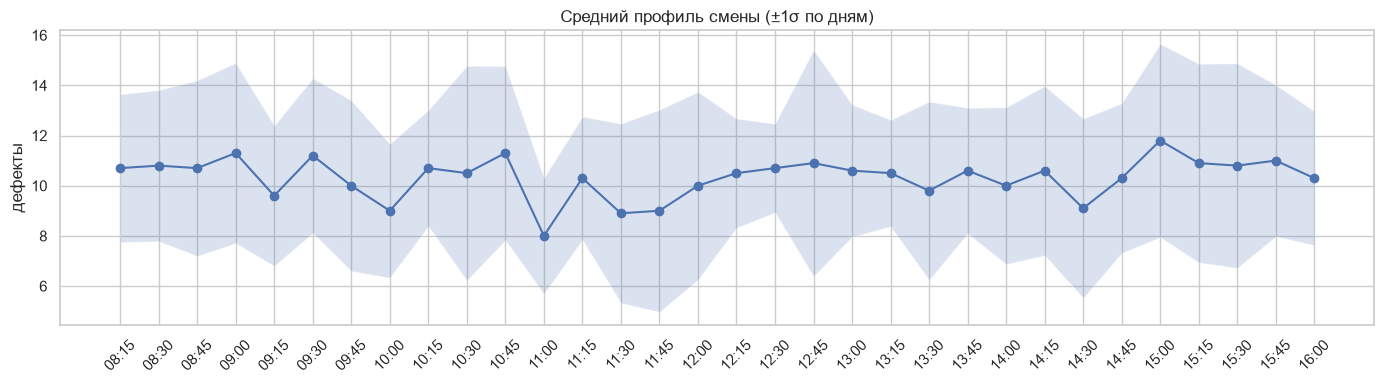

Самые спокойные слоты:
   Sample  mean   std
11  11:00   8.0  2.31
13  11:30   8.9  3.57
7   10:00   9.0  2.67
14  11:45   9.0  4.03
25  14:30   9.1  3.57
Самые проблемные слоты:
   Sample  mean   std
27  15:00  11.8  3.85
3   09:00  11.3  3.59
10  10:45  11.3  3.47
5   09:30  11.2  3.08
30  15:45  11.0  3.02


In [25]:
slot_profile = (
    df.groupby("Sample")["Defects"]
      .agg(mean="mean", std="std", median="median")
      .reset_index()
)

plt.figure(figsize=(14, 4))
x = np.arange(len(slot_profile))
plt.plot(x, slot_profile["mean"], marker="o")
plt.fill_between(
    x,
    slot_profile["mean"] - slot_profile["std"],
    slot_profile["mean"] + slot_profile["std"],
    alpha=0.2,
)
plt.xticks(x, slot_profile["Sample"], rotation=45)
plt.title("Средний профиль смены (±1σ по дням)")
plt.ylabel("дефекты")
plt.tight_layout()
plt.show()

print("Самые спокойные слоты:")
print(slot_profile.nsmallest(5, "mean")[["Sample", "mean", "std"]].round(2))
print("Самые проблемные слоты:")
print(slot_profile.nlargest(5, "mean")[["Sample", "mean", "std"]].round(2))


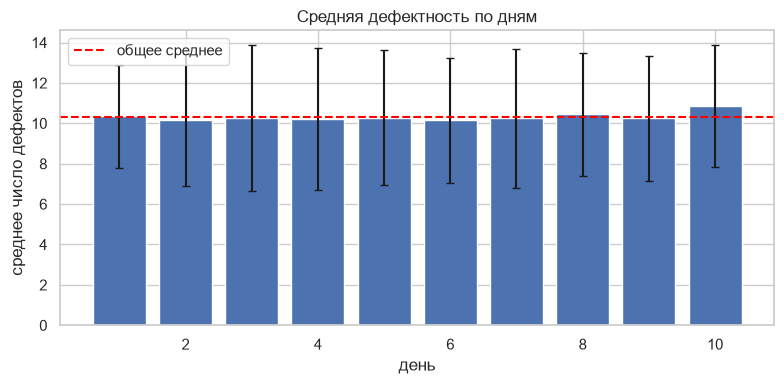

      mean   std  max
Day                  
1    10.34  2.54   15
2    10.16  3.28   17
3    10.28  3.62   17
4    10.22  3.51   16
5    10.28  3.33   17
6    10.16  3.09   17
7    10.25  3.45   16
8    10.44  3.04   17
9    10.25  3.10   16
10   10.88  3.02   18


In [27]:
day_profile = df.groupby("Day")["Defects"].agg(mean="mean", std="std", max="max")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(day_profile.index.astype(int), day_profile["mean"], yerr=day_profile["std"], capsize=3)
ax.axhline(df["Defects"].mean(), color="red", ls="--", label="общее среднее")
ax.set_xlabel("день")
ax.set_ylabel("среднее число дефектов")
ax.set_title("Средняя дефектность по дням")
ax.legend()
plt.tight_layout()
plt.show()

print(day_profile.round(2))


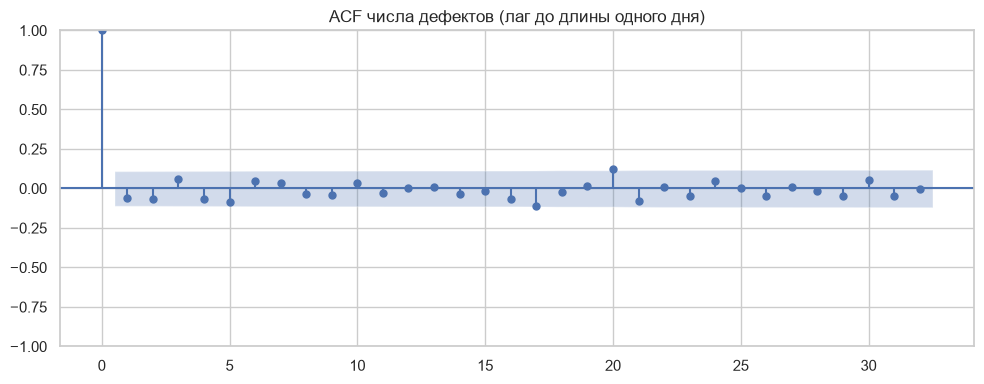

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df["Defects"], lags=32, ax=ax)
ax.set_title("ACF числа дефектов (лаг до длины одного дня)")
plt.tight_layout()
plt.show()


# Этап 2. Контроль качества

Ниже карта Шухарта с границами `μ ± 3s`. Дальше — **c-карта** с границами `μ ± 3√μ` (так корректнее для счёта дефектов), EWMA и CUSUM: они ловят небольшой, но устойчивый подъём раньше, чем точка выйдет за 3σ.


Среднее: 10.325
Стандартное отклонение: 3.172
UCL = 19.842
LCL = 0.808
Точки вне контроля:
Empty DataFrame
Columns: [t, Defects]
Index: []


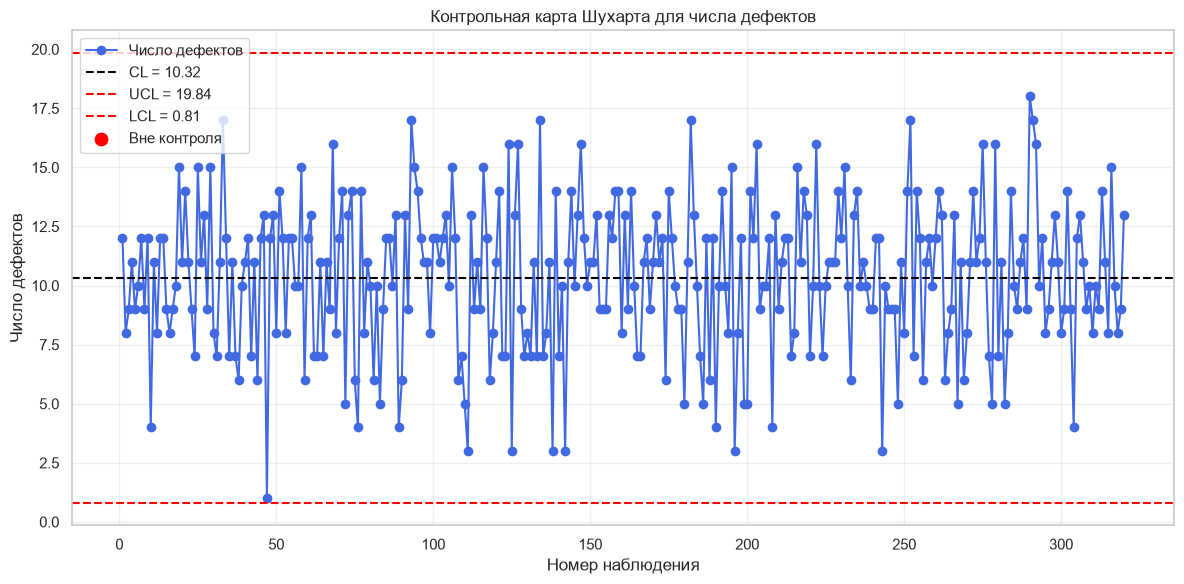

In [30]:
# --- Шухарт для числа дефектов ---
mean_val = df["Defects"].mean()
std_val = df["Defects"].std(ddof=1)

ucl = mean_val + 3 * std_val
lcl = max(mean_val - 3 * std_val, 0)

# флаг точек вне контроля
out_of_control = (df["Defects"] > ucl) | (df["Defects"] < lcl)

df["out_of_control"] = out_of_control

print(f"Среднее: {mean_val:.3f}")
print(f"Стандартное отклонение: {std_val:.3f}")
print(f"UCL = {ucl:.3f}")
print(f"LCL = {lcl:.3f}")
print("Точки вне контроля:")
print(df.loc[out_of_control, ["t", "Defects"]])

plt.figure(figsize=(12, 6))
plt.plot(df["t"], df["Defects"], marker="o", color="royalblue", linewidth=1.5, label="Число дефектов")
plt.axhline(mean_val, color="black", linestyle="--", linewidth=1.5, label=f"CL = {mean_val:.2f}")
plt.axhline(ucl, color="red", linestyle="--", linewidth=1.5, label=f"UCL = {ucl:.2f}")
plt.axhline(lcl, color="red", linestyle="--", linewidth=1.5, label=f"LCL = {lcl:.2f}")
plt.scatter(df.loc[out_of_control, "t"], df.loc[out_of_control, "Defects"], color="red", s=80, zorder=5, label="Вне контроля")
plt.title("Контрольная карта Шухарта для числа дефектов")
plt.xlabel("Номер наблюдения")
plt.ylabel("Число дефектов")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Среднее: 10.325
Стандартное отклонение: 3.172
UCL = 19.842
LCL = 0.808
Точки вне контроля по времени:
Empty DataFrame
Columns: [timestamp, hour, minute, Defects]
Index: []


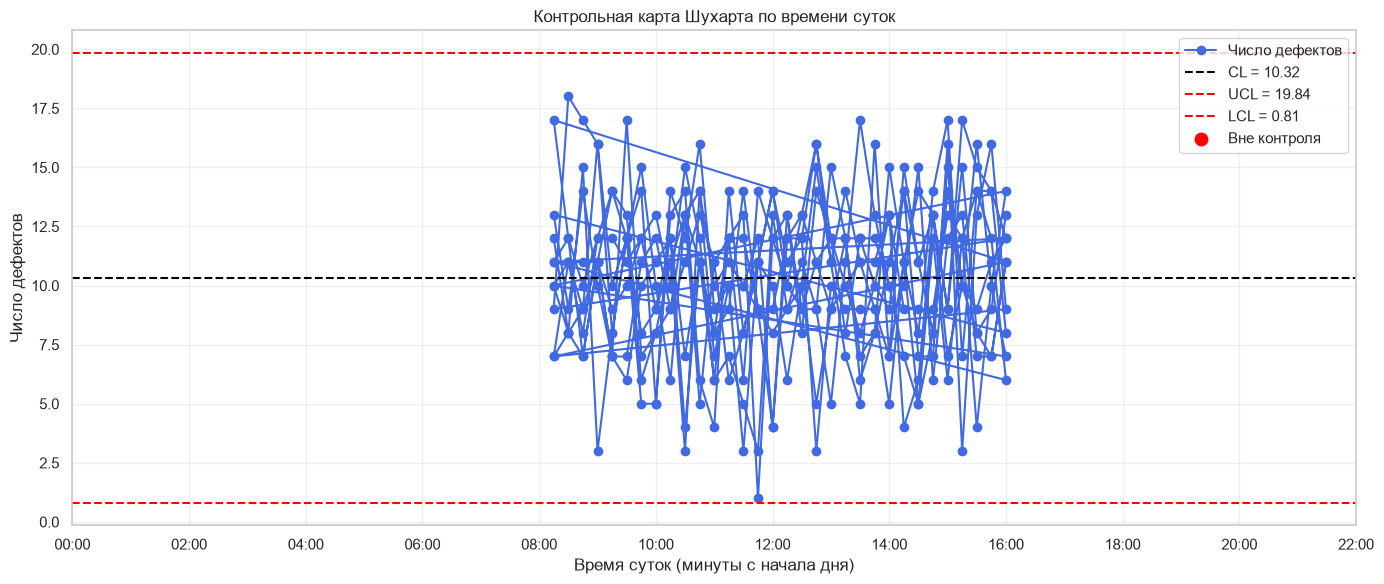

In [31]:
# --- Шухарт по времени суток (часы + минуты) ---
df["hour"] = df["Sample_dt"].dt.hour
df["minute"] = df["Sample_dt"].dt.minute
df["minute_of_day"] = df["hour"] * 60 + df["minute"]

mean_time = df["Defects"].mean()
std_time = df["Defects"].std(ddof=1)

ucl_time = mean_time + 3 * std_time
lcl_time = max(mean_time - 3 * std_time, 0)

df["out_of_control_time"] = (df["Defects"] > ucl_time) | (df["Defects"] < lcl_time)

print(f"Среднее: {mean_time:.3f}")
print(f"Стандартное отклонение: {std_time:.3f}")
print(f"UCL = {ucl_time:.3f}")
print(f"LCL = {lcl_time:.3f}")
print("Точки вне контроля по времени:")
print(df.loc[df["out_of_control_time"], ["timestamp", "hour", "minute", "Defects"]])

plt.figure(figsize=(14, 6))
plt.plot(df["minute_of_day"], df["Defects"], marker="o", color="royalblue", linewidth=1.5, label="Число дефектов")
plt.axhline(mean_time, color="black", linestyle="--", linewidth=1.5, label=f"CL = {mean_time:.2f}")
plt.axhline(ucl_time, color="red", linestyle="--", linewidth=1.5, label=f"UCL = {ucl_time:.2f}")
plt.axhline(lcl_time, color="red", linestyle="--", linewidth=1.5, label=f"LCL = {lcl_time:.2f}")
plt.scatter(
    df.loc[df["out_of_control_time"], "minute_of_day"],
    df.loc[df["out_of_control_time"], "Defects"],
    color="red", s=80, zorder=5, label="Вне контроля"
)
plt.title("Контрольная карта Шухарта по времени суток")
plt.xlabel("Время суток (минуты с начала дня)")
plt.ylabel("Число дефектов")
plt.xticks(np.arange(0, 1440, 120), [f"{h:02d}:00" for h in range(0, 24, 2)])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()